In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
val = pd.read_parquet('data/val.parquet')

In [3]:
x_cols = ['Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y', 
          'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count', 
          'Packet speed_y_normalized', 'Data speed_y_normalized', 'time_of_day',
          'Avg packet len_y_normalized', 'total_seconds', 'weekday_number', 
          'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 
          'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount', 
          'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 
          'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 
          'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 
          'Is_DNS', 'Is_POP3', 'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 
          'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 'Is_TFTP', 'Is_MySQL', 
          'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081', 
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 
          'Is_NTP', 'Is_Kerberos', 'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 
          'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 'Is_BGP', 'Is_IMAPS_Alt', 
          'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 
          'Is_Modbus', 'Is_CoAP', 'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 
          'Is_Elasticsearch', 'Is_Zookeeper', 'Is_Cassandra', 'Is_Docker', 
          'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 'Is_DHCPv6', 
          'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH']

In [4]:
def evaluate(model):
    model.fit(train[x_cols], train['Type'])

    # Predict the labels for the test data
    test['pred'] = model.predict(val[x_cols])

    # Generate the classification report
    report = classification_report(val['pred'], val['Type'])

    # Print the classification report
    print(report)
    # 1. Generate the confusion matrix
    cm = confusion_matrix(val['Type'], val['pred'])

    # 2. Visualize the confusion matrix (optional, but highly recommended)
    class_labels = np.unique(val['Type']) # Get unique class labels

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Print the confusion matrix (textual representation)
    print(cm)

    # 1. Generate the classification report as a dictionary
    report = classification_report(val['Type'], val['pred'], output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1_score = [report[cls]['f1-score'] for cls in classes]

    # 3. Set up the plot
    x = np.arange(len(classes))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision, width, label='Recall')
    rects2 = ax.bar(x, recall, width, label='Precision')
    rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_xlabel('Classes')
    ax.set_title('Classification Report per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.bar_label(rects3, fmt='%.2f', padding=3)

    fig.tight_layout()
    plt.show()

# RFC


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
{'n_estimators': 437, 'max_depth': 37, 'min_samples_split': 10, 'min_samples_leaf': 5}
rfc = RandomForestClassifier(n_estimators=437, random_state=42, max_depth=37, min_samples_split=10, min_samples_leaf=5, verbose=1)

evaluate(rfc)

In [6]:
# After SMOTE *2
"""Accuracy: 0.8212698814847835
Precision: 0.6796352669253373
Recall: 0.5641607988228415
F1-Score: 0.5968541729821948"""

# After SMOTE *1.5
"""Accuracy: 0.8317616290350254
Precision: 0.8383765643300584
Recall: 0.5832465366868779
F1-Score: 0.6230823834637998"""

# After SMOTE *1.2
"""Accuracy: 0.8205282594089793
Precision: 0.8171876601009965
Recall: 0.5604558516901181
F1-Score: 0.6038335264459057"""

# After SMOTE *1.7
"""Accuracy: 0.7814820575562871
Precision: 0.5873932085311964
Recall: 0.6415121998728757
F1-Score: 0.599508817810126"""



# ROUND 2
"""Accuracy: 0.8412231232150961
Precision: 0.8303405069778947
Recall: 0.5715682661763412
F1-Score: 0.618068275503768"""

'Accuracy: 0.8412231232150961\nPrecision: 0.8303405069778947\nRecall: 0.5715682661763412\nF1-Score: 0.618068275503768'

# GBM


      Iter       Train Loss   Remaining Time 
         1           0.5073           60.16m
         2           0.4697           59.52m
         3           0.4429           58.79m
         4           0.4191           58.44m
         5           0.3994           57.91m
         6           0.3843           57.46m
         7           0.3698           56.77m
         8           0.3568           56.00m
         9           0.3454           55.46m
        10           0.3343           54.83m
        20           0.2641           48.72m
        30           0.2274           42.54m
        40           0.2059           36.34m
        50           0.1865           30.24m
        60           0.1710           24.24m
        70           0.1577           18.16m
        80           0.1467           12.09m
        90           0.1365            6.05m
       100           0.1277            0.00s
              precision    recall  f1-score   support

           0       0.54      0.57      0.56 

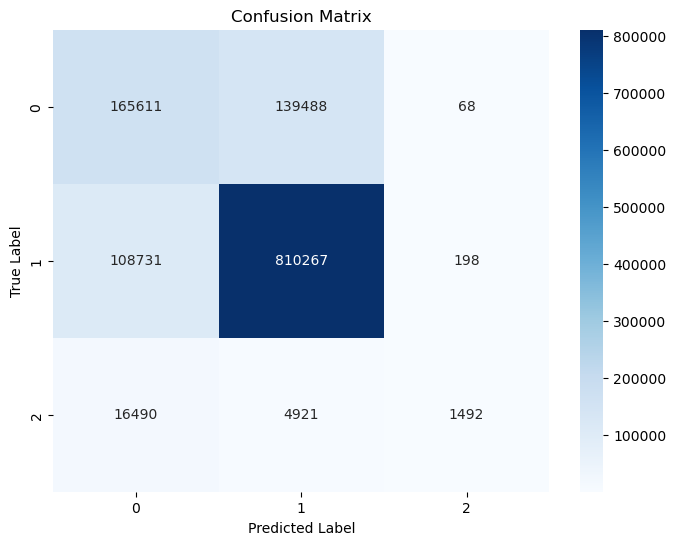

[[165611 139488     68]
 [108731 810267    198]
 [ 16490   4921   1492]]


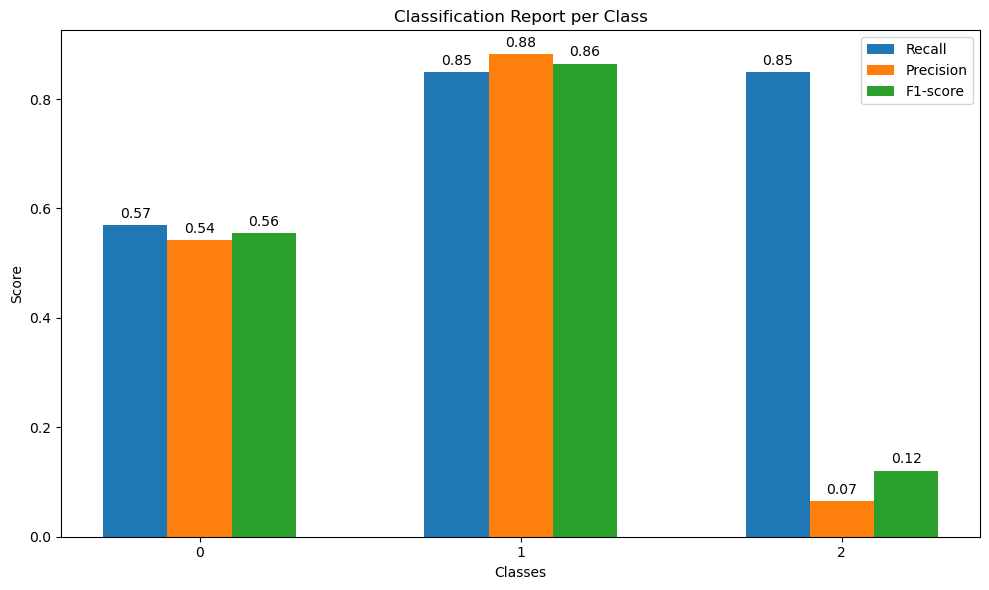

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier
# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42, verbose=1)

evaluate(gbc)

In [ ]:
# After SMOTE *1.5
"""Accuracy: 0.7537750568042423
Precision: 0.5499038794403751
Recall: 0.6752129126613243
F1-Score: 0.5814952853168204"""

# XGBoost


              precision    recall  f1-score   support

           0       0.56      0.63      0.59    271802
           1       0.90      0.86      0.88    966540
           2       0.23      0.58      0.32      8924

    accuracy                           0.80   1247266
   macro avg       0.56      0.69      0.60   1247266
weighted avg       0.82      0.80      0.81   1247266



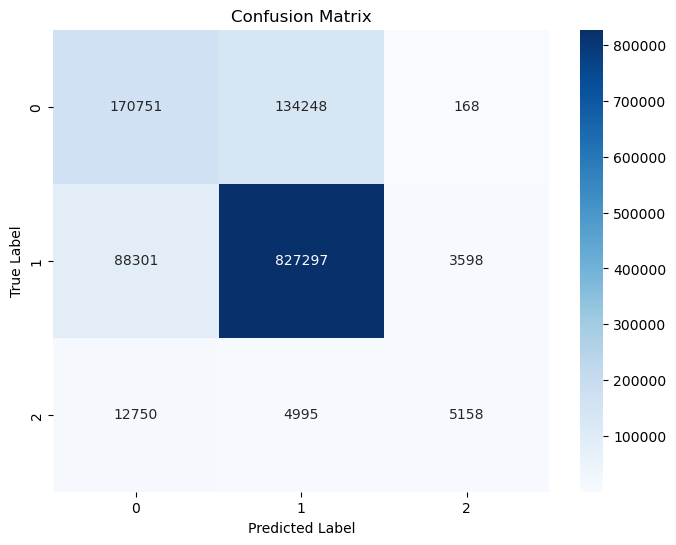

[[170751 134248    168]
 [ 88301 827297   3598]
 [ 12750   4995   5158]]


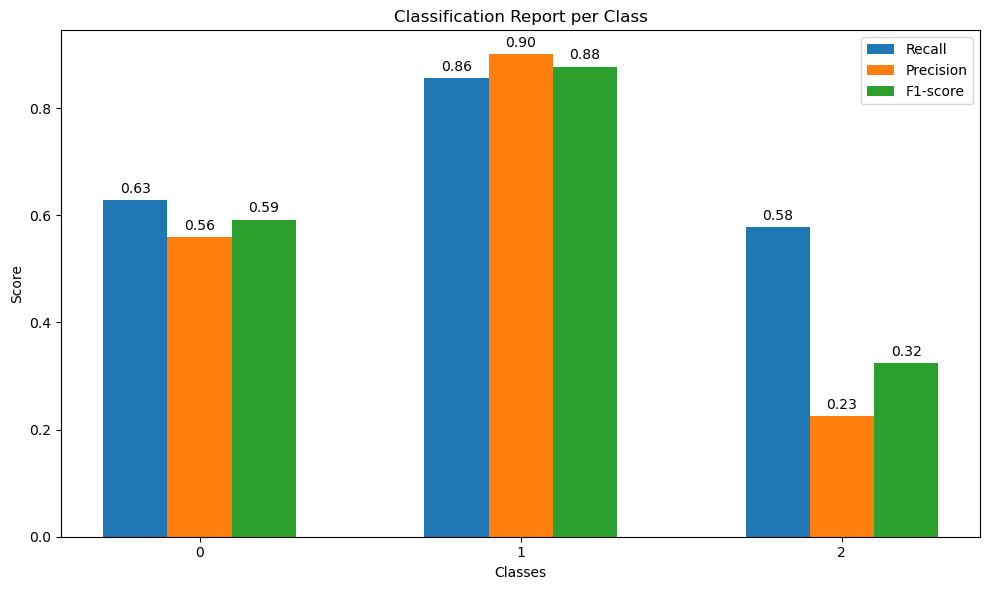

In [ ]:
import xgboost
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# xgboost for classification
from numpy import asarray
from numpy import mean
from numpy import std
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from matplotlib import pyplot
# evaluate the model
xgbm = XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('gbtree'),
        alpha=0.8929914624140356,
        subsample=0.5245590585473099,
        colsample_bytree=0.41745486572446977,
        max_depth=10,
        eta=0.03343544751435021,
        gamma=0.36103800824329335,
        grow_policy='lossguide',
        min_child_weight=2,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42,)

evaluate(xgbm)

In [37]:
#w smote
"""Accuracy: 0.761876776886406
Precision: 0.5359084300770789
Recall: 0.5724204312974694
F1-Score: 0.5501817911228063"""

#w smote
"""Accuracy: 0.7828698930300353
Precision: 0.7618986989713181
Recall: 0.5156758740397258
F1-Score: 0.5646436798588266"""

'Accuracy: 0.7828698930300353\nPrecision: 0.7618986989713181\nRecall: 0.5156758740397258\nF1-Score: 0.5646436798588266'

# LightGBM


              precision    recall  f1-score   support

           0       0.67      0.60      0.63    338482
           1       0.87      0.88      0.87    899947
           2       0.22      0.56      0.31      8837

    accuracy                           0.81   1247266
   macro avg       0.58      0.68      0.61   1247266
weighted avg       0.81      0.81      0.80   1247266



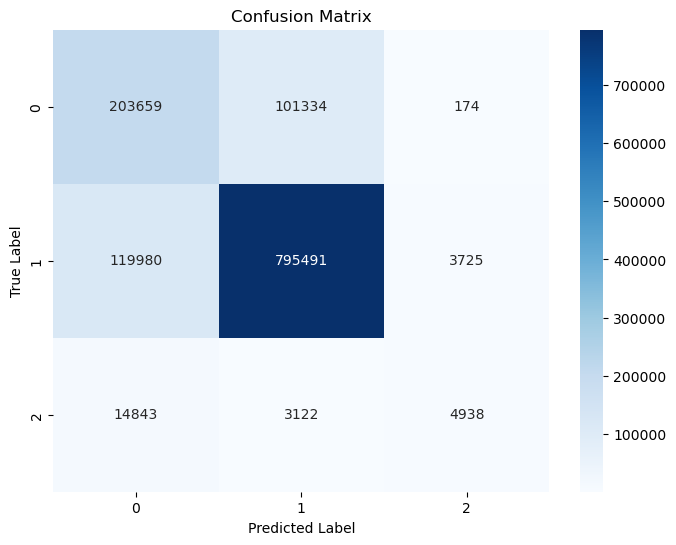

[[203659 101334    174]
 [119980 795491   3725]
 [ 14843   3122   4938]]


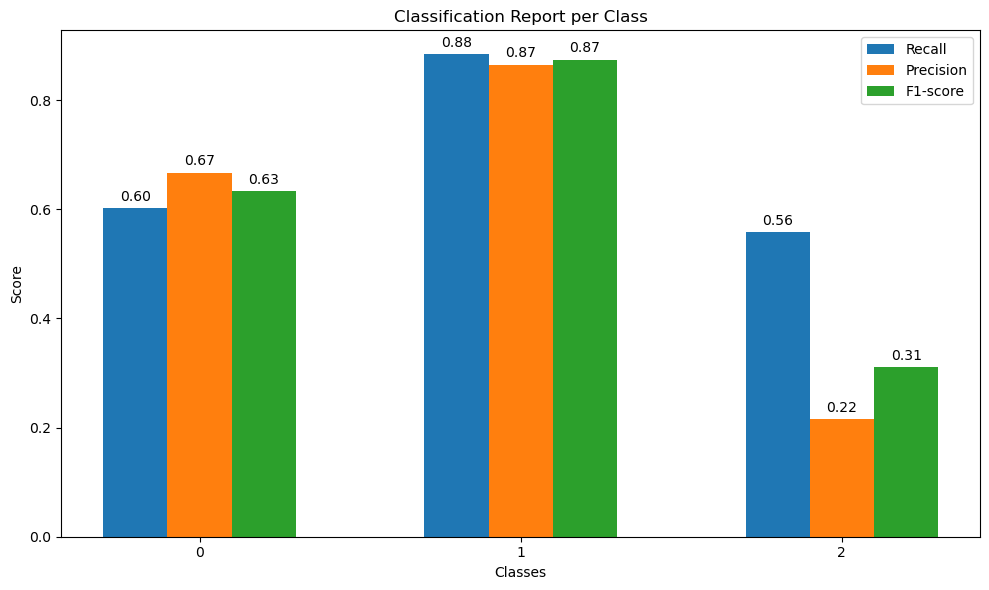

In [7]:
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, 
                          min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
evaluate(lgbm)

In [39]:
#w smote
"""Accuracy: 0.8111389230525005
Precision: 0.670946848156344
Recall: 0.5834843327517265
F1-Score: 0.6068882307103756"""
#wo smote
"""Accuracy: 0.7763556450668903
Precision: 0.6314237782732396
Recall: 0.5448904317256309
F1-Score: 0.5687628012192705"""

'Accuracy: 0.7763556450668903\nPrecision: 0.6314237782732396\nRecall: 0.5448904317256309\nF1-Score: 0.5687628012192705'

# CatBoost


Learning rate set to 0.116035
0:	learn: 0.9398561	total: 325ms	remaining: 5m 24s
1:	learn: 0.8253582	total: 623ms	remaining: 5m 10s
2:	learn: 0.7386392	total: 928ms	remaining: 5m 8s
3:	learn: 0.6668613	total: 1.23s	remaining: 5m 6s
4:	learn: 0.6112182	total: 1.51s	remaining: 5m 1s
5:	learn: 0.5643127	total: 1.8s	remaining: 4m 58s
6:	learn: 0.5243586	total: 2.12s	remaining: 5m 1s
7:	learn: 0.4892534	total: 2.46s	remaining: 5m 5s
8:	learn: 0.4571585	total: 2.77s	remaining: 5m 5s
9:	learn: 0.4324592	total: 3.1s	remaining: 5m 7s
10:	learn: 0.4098580	total: 3.41s	remaining: 5m 7s
11:	learn: 0.3916232	total: 3.72s	remaining: 5m 6s
12:	learn: 0.3724859	total: 4.03s	remaining: 5m 6s
13:	learn: 0.3563195	total: 4.34s	remaining: 5m 5s
14:	learn: 0.3420273	total: 4.66s	remaining: 5m 5s
15:	learn: 0.3297294	total: 5s	remaining: 5m 7s
16:	learn: 0.3168866	total: 5.3s	remaining: 5m 6s
17:	learn: 0.3051884	total: 5.65s	remaining: 5m 8s
18:	learn: 0.2946740	total: 5.97s	remaining: 5m 8s
19:	learn: 0.2

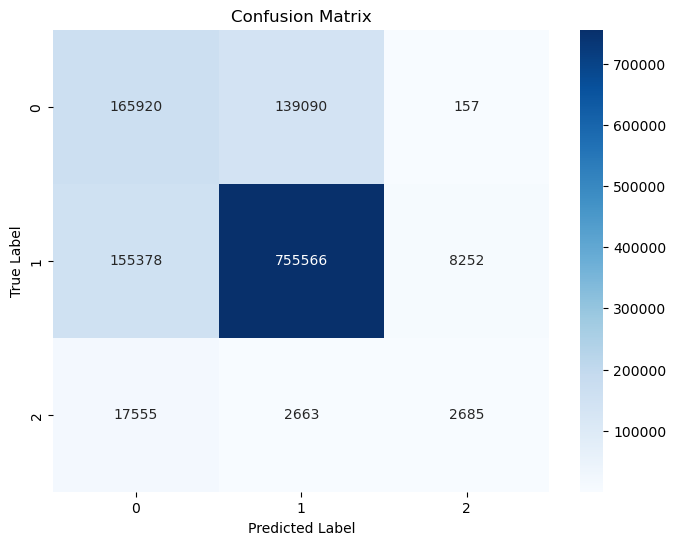

[[165920 139090    157]
 [155378 755566   8252]
 [ 17555   2663   2685]]


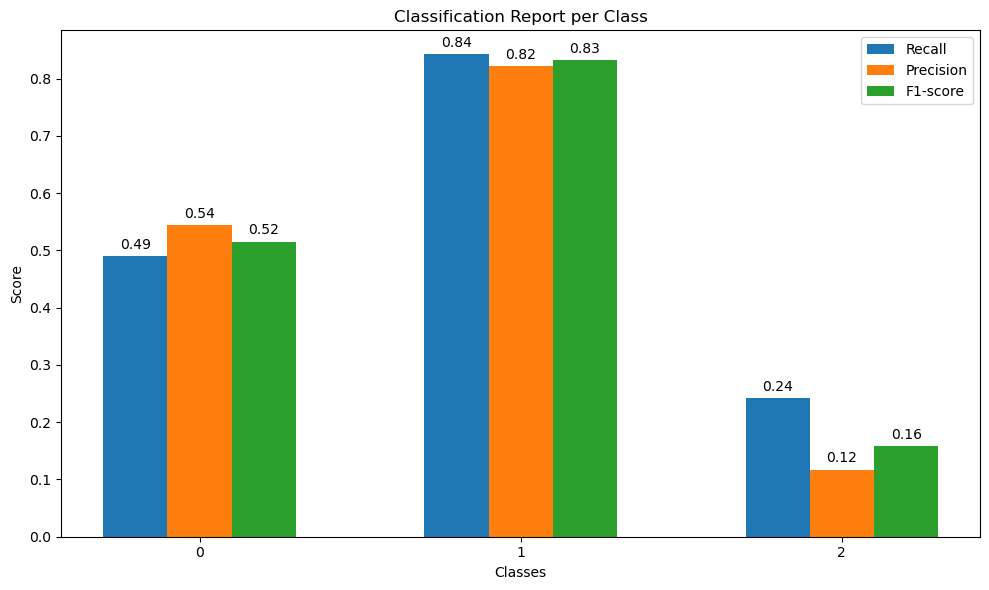

In [40]:
# check catboost version
import catboost as cat
cgbm = cat.CatBoostClassifier(verbose=1, random_seed=42, loss_function='MultiClass')

evaluate(cgbm)

In [ ]:
#w smote
"""Accuracy: 0.7763556450668903
Precision: 0.6314237782732396
Recall: 0.5448904317256309
F1-Score: 0.5687628012192705"""
#w smote
"""Accuracy: 0.7992240628703099
Precision: 0.6110429618065945
Recall: 0.5628038211345253
F1-Score: 0.5825504082708981"""

# SVM


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 4. Create and train the SVC model (it handles multi-class by default - OVR)
svm_multi = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)  # Example hyperparameters
svm_multi.fit(train[x_cols], train['Type'])

# 5. Make predictions
test['pred'] = svm_multi.predict(test[x_cols])

# Example metrics calculation
accuracy = accuracy_score(test['Type'], test['pred'])
print("Accuracy:", accuracy)
precision = precision_score(test['Type'], test['pred'], average='macro')
print("Precision:", precision)
recall = recall_score(test['Type'], test['pred'], average='macro')
print("Recall:", recall)
f1 = f1_score(test['Type'], test['pred'], average='macro')
print("F1-Score:", f1)

# Verdict


In [ ]:
# RFC
    # After SMOTE *2
    """Accuracy: 0.8212698814847835
    Precision: 0.6796352669253373
    Recall: 0.5641607988228415
    F1-Score: 0.5968541729821948"""
    
    # After SMOTE *1.5
    """Accuracy: 0.8317616290350254
    Precision: 0.8383765643300584
    Recall: 0.5832465366868779
    F1-Score: 0.6230823834637998"""
    
    # After SMOTE *1.2
    # After SMOTE *1.7

# GBC
    # After SMOTE *2
    """Accuracy: 0.7427100554332436
    Precision: 0.5302445031077706
    Recall: 0.6432907285227544
    F1-Score: 0.5557385293452168"""
    
    # After SMOTE *1.5
    """Accuracy: 0.7537750568042423
    Precision: 0.5499038794403751
    Recall: 0.6752129126613243
    F1-Score: 0.5814952853168204"""

In [ ]:
# CNN
    #simple simply
    """Test Loss:     11098.7607
    Test Accuracy: 0.7891"""
    #simple smote
    """Test Loss:     10123.3623
    Test Accuracy: 0.7939"""
    
    #complex simply
    """Test Loss:     0.6736
    Test Accuracy: 0.7370"""
    #complex smote
    """Test Loss:     0.6572
    Test Accuracy: 0.7370"""